# Pythia EFPs, Underparametrized Regime

Compares the EFP covariance eigenspectrum for two processes at the same center-of-mass energy (sqrt(s) = mZ = 91.188 GeV):
- **e+e- → Z → qqbar** (light quarks u, d, s)
- **e+e- → H → gg** with mH = mZ (gluon jets)

Events are generated with Pythia8. EFPs are computed with [EnergyFlow](https://energyflow.network) package.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import energyflow as ef
from energyflow.utils import gen_massless_phase_space
from energyflow import EFPSet
import os
from RegressFunctions import *
from RestrictedEFPs import efps_chunked
from PhysicsFunctions import *

os.makedirs('figures', exist_ok=True)

## Load Pythia Events

Text format: one particle per line (`E px py pz`), blank line between events.

In [2]:
def load_events(filepath):
    events, current = [], []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line:
                current.append([float(x) for x in line.split()])
            elif current:
                events.append(np.array(current))
                current = []
    if current:
        events.append(np.array(current))
    return events

Zqq_events = load_events('data/Zqq_events.txt')
Hgg_events = load_events('data/Hgg_events.txt')


mults_Z = [len(e) for e in Zqq_events]
mults_H = [len(e) for e in Hgg_events]
print(f'Z->qqbar: {len(Zqq_events)} events, avg multiplicity {np.mean(mults_Z):.1f} +/- {np.std(mults_Z):.1f}')
print(f'H->gg:    {len(Hgg_events)} events, avg multiplicity {np.mean(mults_H):.1f} +/- {np.std(mults_H):.1f}')

Z->qqbar: 100000 events, avg multiplicity 12.4 +/- 4.2
H->gg:    100000 events, avg multiplicity 19.9 +/- 5.2


In [3]:
#### Uniform Phase Space ####

NEvents=100_000
uniform_N3 = gen_massless_phase_space(NEvents,3,energy=1.0)
uniform_N5 = gen_massless_phase_space(NEvents,5,energy=1.0)
uniform_N7 = gen_massless_phase_space(NEvents,7,energy=1.0)
uniform_N10 = gen_massless_phase_space(NEvents,10,energy=1.0)

# efpset = EFPSet(('d<=', 6), measure='eeefm', beta=2,coords='epxpypz')

## Compute EFPs

Using `measure='ee'` (appropriate for e+e- events), which uses energy fractions z_i = E_i / sum(E_j) and pairwise angles theta_ij computed from the 3-momenta directions.

Input to `batch_compute`: list of (N_particles, 4) arrays with columns (E, px, py, pz).

In [ ]:
efpset = ef.EFPSet(('d<=', 3),  measure='eeefm', beta=2, normed=True, coords='epxpypz')
print(f'EFP basis: {efpset.count()} EFPs')

EFPs_N3 = efpset.batch_compute(uniform_N3);   print('uniform N=3 done')
EFPs_N5 = efpset.batch_compute(uniform_N5);   print('uniform N=5 done')
# EFPs_N7 = efpset.batch_compute(uniform_N7);   print('uniform N=7 done')
# EFPs_N10 = efpset.batch_compute(uniform_N10);   print('uniform N=10 done')

# EFPs_Zqq = efpset.batch_compute(Zqq_events); print('Z->qqbar done')
# EFPs_Hgg = efpset.batch_compute(Hgg_events); print('H->gg done')


EFP basis: 13 EFPs


In [4]:
#####################
## Restricted EFPs ##
#####################
EFPs_N3_restricted = efps_chunked(uniform_N3, dmax=8, device='cpu', chunk=5000).numpy()
EFPs_N5_restricted = efps_chunked(uniform_N5, dmax=8, device='cpu', chunk=5000).numpy()
EFPs_N7_restricted = efps_chunked(uniform_N7, dmax=8, device='cpu', chunk=5000).numpy()
EFPs_N10_restricted = efps_chunked(uniform_N10, dmax=8, device='cpu', chunk=5000).numpy()
print(f'Restricted EFP basis: {EFPs_N3_restricted.shape} EFPs')

Restricted EFP basis: (100000, 32) EFPs


In [5]:
####################
## Composite EFPs ##
####################
EFPs_N3_restricted_composite = np.einsum('na,nb->nab', EFPs_N3_restricted, EFPs_N3_restricted).reshape(len(EFPs_N3_restricted), -1)
EFPs_N5_restricted_composite = np.einsum('na,nb->nab', EFPs_N5_restricted, EFPs_N5_restricted).reshape(len(EFPs_N5_restricted), -1)
EFPs_N7_restricted_composite = np.einsum('na,nb->nab', EFPs_N7_restricted, EFPs_N7_restricted).reshape(len(EFPs_N7_restricted), -1)
EFPs_N10_restricted_composite = np.einsum('na,nb->nab', EFPs_N10_restricted, EFPs_N10_restricted).reshape(len(EFPs_N10_restricted), -1)
print(EFPs_N5_restricted_composite.shape)  

EFPs_N3_composite = np.einsum('na,nb->nab', EFPs_N3, EFPs_N3).reshape(len(EFPs_N3), -1)
EFPs_N5_composite = np.einsum('na,nb->nab', EFPs_N5, EFPs_N5).reshape(len(EFPs_N5), -1)
EFPs_N7_composite = np.einsum('na,nb->nab', EFPs_N7, EFPs_N7).reshape(len(EFPs_N7), -1)
EFPs_N10_composite = np.einsum('na,nb->nab', EFPs_N10, EFPs_N10).reshape(len(EFPs_N10), -1)
EFPs_Zqq_composite = np.einsum('na,nb->nab', EFPs_Zqq, EFPs_Zqq).reshape(len(EFPs_Zqq), -1)
EFPs_Hgg_composite = np.einsum('na,nb->nab', EFPs_Hgg, EFPs_Hgg).reshape(len(EFPs_Hgg), -1)

print(EFPs_N5_composite.shape)  


(100000, 1024)


NameError: name 'EFPs_N3' is not defined

In [ ]:
# Log
eps = 1e-10
log_EFPs_Zqq = np.log(EFPs_Zqq + eps)
log_EFPs_Hgg = np.log(EFPs_Hgg + eps)
log_EFPs_N3  = np.log(EFPs_N3  + eps)
log_EFPs_N5  = np.log(EFPs_N5  + eps)
log_EFPs_N7  = np.log(EFPs_N7  + eps)
log_EFPs_N10  = np.log(EFPs_N10  + eps)


### Covariance Matrix

In [ ]:
cov_u3 = np.cov(EFPs_N3.T)
cov_u5 = np.cov(EFPs_N5.T)
cov_u7 = np.cov(EFPs_N7.T)
cov_u10 = np.cov(EFPs_N10.T)
cov_Z = np.cov(EFPs_Zqq.T) 
cov_H = np.cov(EFPs_Hgg.T)

cov_u3_comp = np.cov(EFPs_N3_composite.T)
cov_u5_comp = np.cov(EFPs_N5_composite.T)
cov_u7_comp = np.cov(EFPs_N7_composite.T)
cov_u10_comp = np.cov(EFPs_N10_composite.T)
cov_Z_comp = np.cov(EFPs_Zqq_composite.T) 
cov_H_comp = np.cov(EFPs_Hgg_composite.T)

print(f'Covariance matrix shape: {cov_Z.shape}')

Covariance matrix shape: (36, 36)


### Eigenspectrum

In [ ]:
samples = [('Z->qqbar', cov_Z), ('H->gg', cov_H),
           ('uniform N=3', cov_u3), ('uniform N=5', cov_u5),
           ('uniform N=7', cov_u7), ('uniform N=10', cov_u10)]

samples_comp = [('Z->qqbar', cov_Z_comp), ('H->gg', cov_H_comp),
                ('uniform N=3', cov_u3_comp), ('uniform N=5', cov_u5_comp),
                ('uniform N=7', cov_u7_comp), ('uniform N=10', cov_u10_comp)]

eigvals, eigvals_comp = {}, {}
for name, cov in samples:
    ev = np.clip(np.sort(np.linalg.eigvalsh(cov))[::-1], 0, None)
    eigvals[name] = ev
    print(f'{name}: largest = {ev[0]:.4e}, smallest = {ev[-1]:.4e}')
for name, cov in samples_comp:
    ev = np.clip(np.sort(np.linalg.eigvalsh(cov))[::-1], 0, None)
    eigvals_comp[name] = ev
    print(f'{name}: largest = {ev[0]:.4e}, smallest = {ev[-1]:.4e}')

Z->qqbar: largest = 5.5481e+02, smallest = 0.0000e+00
H->gg: largest = 6.2032e+02, smallest = 0.0000e+00
uniform N=3: largest = 8.0873e+02, smallest = 0.0000e+00
uniform N=5: largest = 3.8828e+02, smallest = 0.0000e+00
uniform N=7: largest = 2.0652e+02, smallest = 0.0000e+00
uniform N=10: largest = 1.0125e+02, smallest = 0.0000e+00
Z->qqbar: largest = 5.7330e+07, smallest = 0.0000e+00
H->gg: largest = 5.2999e+07, smallest = 0.0000e+00
uniform N=3: largest = 7.6405e+07, smallest = 0.0000e+00
uniform N=5: largest = 2.7581e+07, smallest = 0.0000e+00
uniform N=7: largest = 1.2648e+07, smallest = 0.0000e+00
uniform N=10: largest = 5.4921e+06, smallest = 0.0000e+00


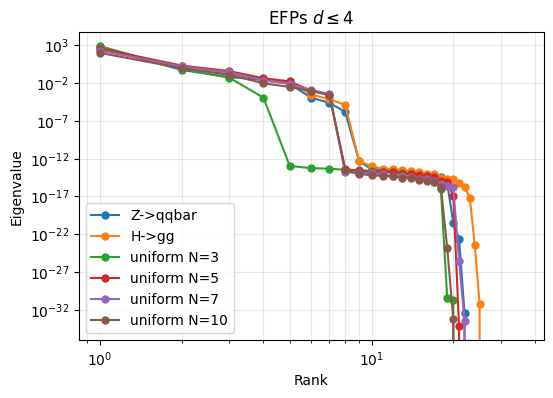

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, ev in eigvals.items():
    ax.loglog(np.arange(1, len(ev)+1), ev, '.-', markersize=10, label=name)
ax.set_xlabel('Rank'); 
ax.set_ylabel('Eigenvalue')
ax.legend(); 
ax.set_title(r'EFPs $d\leq 4$')
ax.grid(True, which='both', alpha=0.3)

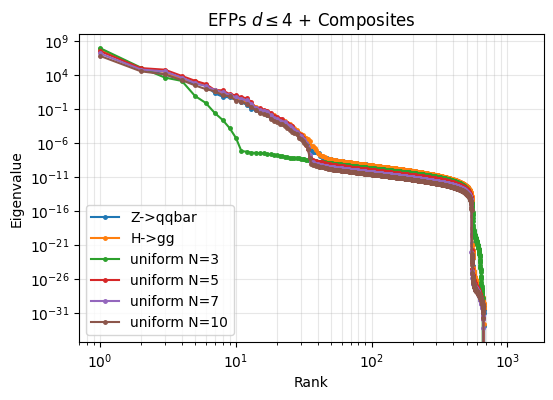

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, ev in eigvals_comp.items():
    ax.loglog(np.arange(1, len(ev)+1), ev, '.-', markersize=5, label=name)
ax.set_xlabel('Rank'); 
ax.set_ylabel('Eigenvalue')
ax.legend(); 
ax.set_title(r'EFPs $d\leq 4$ + Composites')
ax.grid(True, which='both', alpha=0.3)

Z->qqbar: window [100,300] has 0 usable pts, skipped
uniform N=5: window [100,300] has 0 usable pts, skipped


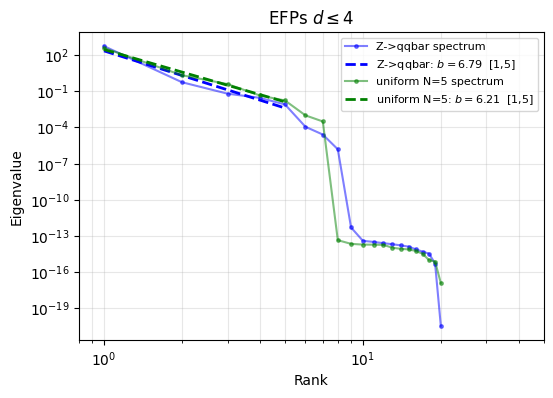

In [ ]:
## ==== Plot EFP covariance spectra with power-law fits ==== ## 
fig, ax = plt.subplots(figsize=(6, 4))

lstyles = ['--', ':']
colors  = ['b', 'g']

###### ======== Spectra ========= ######
names = ['Z->qqbar', 'uniform N=5']
fit_min,  fit_max  = 1, 5
fit_min2, fit_max2 = 100, 300
### ==================================== ### 

for (name, c) in zip(names, colors): 
    ev   = eigvals[name]
    idx  = np.arange(1, len(ev) + 1)
    good = ev > ev[0] * 1e-25
    ax.loglog(idx[good], ev[good], '.-', markersize=5, color=c,
              label=f'{name} spectrum', alpha=0.5)

    for (lo, hi), ls in zip([(fit_min, fit_max), (fit_min2, fit_max2)], lstyles): 
        mask = good & (idx >= lo) & (idx <= hi)
        if mask.sum() < 2:
            print(f'{name}: window [{lo},{hi}] has {mask.sum()} usable pts, skipped')
            continue
        slope, log_c = np.polyfit(np.log(idx[mask]), np.log(ev[mask]), 1)
        ax.loglog(idx[mask], np.exp(log_c) * idx[mask]**slope, ls=ls, color=c, lw=2,
                  label=rf'{name}: $b = {-slope:.2f}$  [{lo},{hi}]')

ax.set_xlabel('Rank'); ax.set_ylabel('Eigenvalue')
ax.set_xlim(0.8,5e1)
ax.set_title(r'EFPs $d\leq 4$')
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)


## Define, Plot Thrust 
Thrust is IRC-safe and well-approximated by low-d EFPs, so the irreducible floor should be near zero.

In [13]:
thrust_samples = {
    'Z->qqbar':    Zqq_events,
    'H->gg':       Hgg_events,
    'uniform N=3': uniform_N3,
    'uniform N=5': uniform_N5,
    'uniform N=7': uniform_N7,
    'uniform N=10': uniform_N10,
}

thrusts = {}
for name, events in thrust_samples.items():
    t = np.array([compute_thrust(e) for e in events])
    thrusts[name] = t
    print(f'{name}: mean thrust = {np.mean(t):.4f} +/- {np.std(t):.4f}')


Z->qqbar: mean thrust = 0.9351 +/- 0.0631
H->gg: mean thrust = 0.8612 +/- 0.0826
uniform N=3: mean thrust = 0.8890 +/- 0.0786
uniform N=5: mean thrust = 0.7703 +/- 0.0880
uniform N=7: mean thrust = 0.7216 +/- 0.0779
uniform N=10: mean thrust = 0.6852 +/- 0.0653


Text(0.5, 0, 'EFP Value')

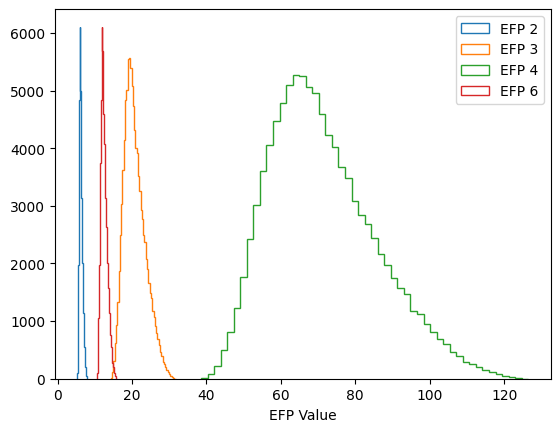

In [14]:
## Plot features ...  
plt.hist(EFPs_N5[:, 2], bins=50, histtype='step', label='EFP 2')
plt.hist(EFPs_N5[:, 3], bins=50, histtype='step', label='EFP 3')
plt.hist(EFPs_N5[:, 4], bins=50, histtype='step', label='EFP 4')
plt.hist(EFPs_N5[:, 6], bins=50, histtype='step', label='EFP 6')
plt.legend(); plt.xlabel('EFP Value')

Text(0.5, 0, 'Thrust')

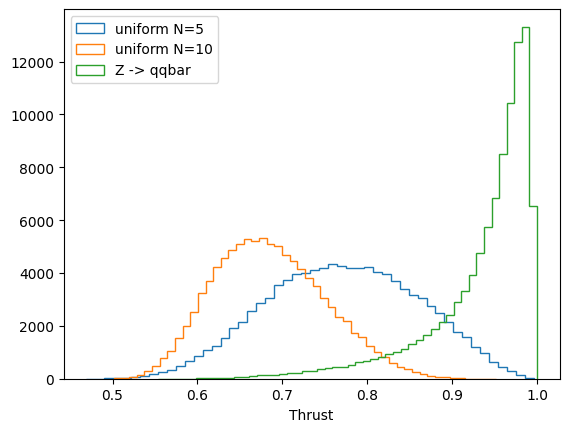

In [15]:
## Plot targets ... 
plt.hist(thrusts['uniform N=5'], bins=50, histtype='step', label='uniform N=5');
plt.hist(thrusts['uniform N=10'], bins=50, histtype='step', label='uniform N=10');
plt.hist(thrusts['Z->qqbar'], bins=50, histtype='step', label='Z -> qqbar');
plt.legend(); plt.xlabel("Thrust")

## Linear Regression: EFPs → Thrust

In [16]:
Ps = np.unique(np.round(np.logspace(0, 4.5, 80)).astype(int))   
print(min(Ps), max(Ps))

1 31623


Composite EFPs -> Thrust Regression

In [17]:
λs = [1e-10]
n_reps = lambda P: max(int(200 / P), 2)
losses_Z_comp, losses_N3_comp, losses_N5_comp, losses_N10_comp = {}, {}, {}, {}
for λ in λs: 
    losses_Z_comp[λ] = run_regression_sweep(EFPs_Zqq_composite,  thrusts['Z->qqbar'], Ps, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                        w_true=None, filter_zero_var=False, center=False, scale=False)
    # losses_N3[r] = run_torch_regression(EFPs_N3_composite,  thrusts['uniform N=3'], train_sizes_t, r=r)
    losses_N5_comp[λ] = run_regression_sweep(EFPs_N5_composite,  thrusts['uniform N=5'], Ps, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                        w_true=None, filter_zero_var=False, center=False, scale=False)
    losses_N10_comp[λ] = run_regression_sweep(EFPs_N10_composite,  thrusts['uniform N=10'], Ps, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                         w_true=None, filter_zero_var=False, center=False, scale=False)
True

       1  |  0.053860
       2  |  0.004003
       3  |  0.000531
       4  |  0.000582
       5  |  0.008198
       6  |  0.002976
       7  |  0.001904
       8  |  0.004930
       9  |  0.007709
      11  |  0.059245
      12  |  0.027434
      14  |  0.021845
      16  |  0.578612
      18  |  0.399095
      20  |  17.405559
      23  |  15.650104
      27  |  0.754936
      30  |  0.102718
      35  |  0.030862
      39  |  0.671191
      45  |  0.004835
      51  |  0.008738
      58  |  0.360962
      66  |  1.140468
      76  |  0.186848
      86  |  0.029809
      99  |  0.758279
     112  |  0.014245
     128  |  0.006478
     146  |  14.067376
     167  |  0.014990
     190  |  0.367982
     216  |  0.001889
     247  |  0.111546
     281  |  0.006813
     321  |  0.016026
     366  |  0.002992
     417  |  0.002534
     476  |  0.437888
     542  |  0.072414
     618  |  0.007642
     705  |  0.233252
     804  |  0.003325
     916  |  0.028554
    1045  |  0.000666
    119

True

EFPs -> Thrust Regression

In [18]:
λs = [1e-10]
n_reps = lambda P: max(int(10_000 / P), 1000)
losses_Z, losses_N3, losses_N5, losses_N10 = {}, {}, {}, {}
for λ in λs: 
    losses_Z[λ]  = run_regression_sweep(EFPs_Zqq, thrusts['Z->qqbar'],  Ps, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                        w_true=None, filter_zero_var=False, center=True, scale=True)
    # losses_N3[r] = run_torch_regression(EFPs_N3_composite,  thrusts['uniform N=3'], train_sizes_t, r=r)
    losses_N5[λ] = run_regression_sweep(EFPs_N5,  thrusts['uniform N=5'], Ps, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                        w_true=None, filter_zero_var=False, center=True, scale=True)
    losses_N10[λ] = run_regression_sweep(EFPs_N10,  thrusts['uniform N=10'], Ps, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                         w_true=None, filter_zero_var=False, center=True, scale=True)

       1  |  0.002640
       2  |  0.000383
       3  |  0.000301
       4  |  0.001001
       5  |  0.002692
       6  |  0.002234
       7  |  0.004635
       8  |  0.001394
       9  |  0.000797
      11  |  0.000505
      12  |  0.000403
      14  |  0.000373
      16  |  0.000325
      18  |  0.000274
      20  |  0.000249
      23  |  0.000212
      27  |  0.000174
      30  |  0.000158
      35  |  0.000134
      39  |  0.000122
      45  |  0.000110
      51  |  0.000102
      58  |  0.000092
      66  |  0.000089
      76  |  0.000079
      86  |  0.000074
      99  |  0.000071
     112  |  0.000064
     128  |  0.000062
     146  |  0.000057
     167  |  0.000055
     190  |  0.000053
     216  |  0.000051
     247  |  0.000049
     281  |  0.000048
     321  |  0.000047
     366  |  0.000046
     417  |  0.000045
     476  |  0.000044
     542  |  0.000043
     618  |  0.000043
     705  |  0.000042
     804  |  0.000042
     916  |  0.000042
    1045  |  0.000041
    1191  

### Plot Learning Curves 

3.9114416868037904e-05
0.0003647433335978632
0.0003279231946316609


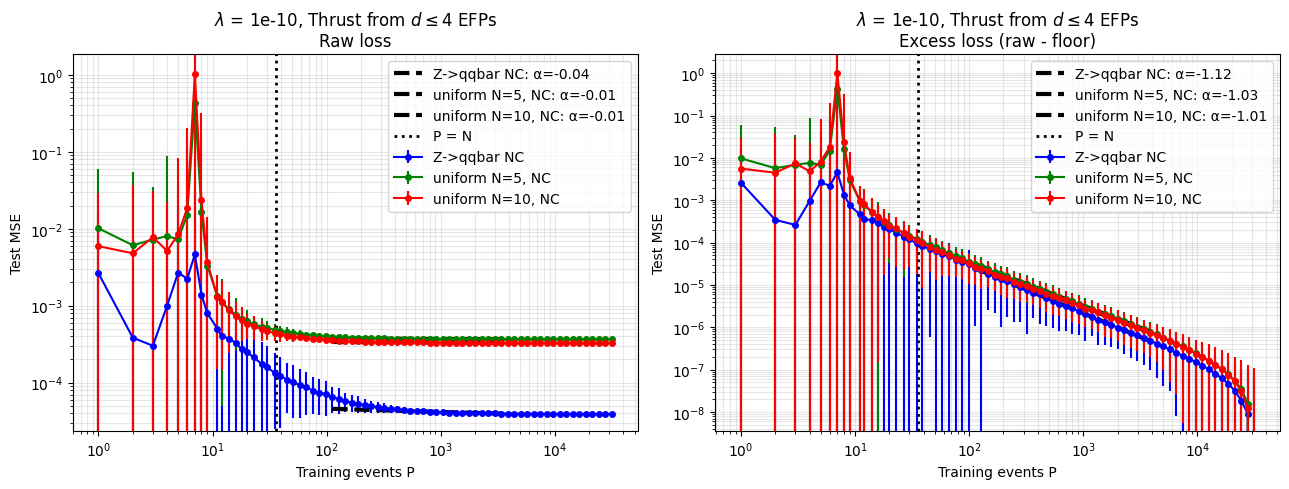

In [19]:
fit_min, fit_max = 100, 4000
ridgeparam=1e-10
all_results = {
    'Z->qqbar NC':    losses_Z[ridgeparam],
    # 'uniform N=3': losses_N3[ridgeparam],
    'uniform N=5, NC': losses_N5[ridgeparam],
    'uniform N=10, NC': losses_N10[ridgeparam],
    # 'uniform N=5, C': losses_N5_comp[ridgeparam],
    # 'uniform N=10, C': losses_N10_comp[ridgeparam],
}
colors = {
    'Z->qqbar NC': 'b', 
        #   'uniform N=3': 'b',
            'uniform N=5, NC': 'g',
            'uniform N=10, NC': 'r',
    # 'uniform N=5, C': 'b',
    # 'uniform N=10, C': 'orange'
            }

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, (losses, stds) in all_results.items():
    color = colors[name]
    floor = losses[-1]
    print(floor)
    # floor = fit_floor(Ps_NC, losses, fit_min, fit_max, p0=None)[2]
    # print(floor)
    excess = np.array(losses) - floor
    ps = np.array(Ps) # np.array(Ps_NC) if name[-2]=='N' else np.array(Ps_C)
    err1 = stds/np.sqrt(np.array([n_reps(p) for p in ps]))
    err2 = stds

    # axes[0].loglog(ps, losses, 'o-', color=color, markersize=4, label=name)
    # axes[1].loglog(ps, excess, 'o-', color=color, markersize=4, label=name)
    axes[0].errorbar(ps, losses, yerr=err2, fmt='o-', color=color, markersize=4, label=name)
    axes[1].errorbar(ps, excess, yerr=err2, fmt='o-', color=color, markersize=4, label=name)
    axes[0].set_xscale('log'); axes[0].set_yscale('log')
    axes[1].set_xscale('log'); axes[1].set_yscale('log')

    for ax, ls in zip(axes, [np.array(losses), excess]):
        mask = (ps >= fit_min) & (ps <= fit_max) & (ls > 0)
        if mask.sum() >= 2:
            slope, log_c = np.polyfit(np.log(ps[mask]), np.log(ls[mask]), 1, w=ls[mask]/err1[mask])

            ax.loglog(ps[mask], np.exp(log_c)*ps[mask]**slope, '--', color='k', linewidth=3,
                      label=f'{name}: α={slope:.2f}')
            # ax.axvspan(fit_min, fit_max, alpha=0.05, color=color)

for ax, title in zip(axes, ['Raw loss', 'Excess loss (raw - floor)']):
    # ax.set_ylim(1e-15, 1e1)
    ax.axvline(np.shape(EFPs_N5)[1], color='k', linestyle=':', linewidth=2, label='P = N')
    ax.set_xlabel('Training events P'); ax.set_ylabel('Test MSE')
    ax.set_title(f'$\lambda$ = 1e-10, Thrust from $d\leq 4$ EFPs\n{title}'); ax.legend(); ax.grid(True, which='both', alpha=0.3)

plt.tight_layout(); plt.show()

Plot the fitted slope vs Pmax

216 18713


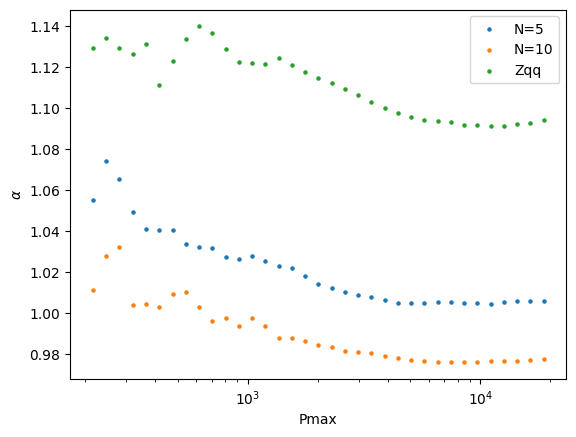

In [21]:
Pmin, Pmax = 100, 20000
Pmaxes = Ps[(Ps > 2*Pmin) & (Ps < Pmax)]
print(min(Pmaxes), max(Pmaxes))
ns = np.array(Ps)
slopes5, slopes10, slopesZqq = [], [], []
slopes5_log, slopes10_log, slopesZqq_log = [], [], []
# Losses
losses5, losses10, lossesZqq = all_results['uniform N=5, NC'][0], all_results['uniform N=10, NC'][0], all_results['Z->qqbar NC'][0]
# Errors
std5, std10, stdZqq = all_results['uniform N=5, NC'][1], all_results['uniform N=10, NC'][1], all_results['Z->qqbar NC'][1]
err1_5, err2_5 = std5/np.sqrt(np.array([n_reps(p) for p in Ps])), std5
err1_10, err2_10 = std10/np.sqrt(np.array([n_reps(p) for p in Ps])), std10
err1_Zqq, err2_Zqq = stdZqq/np.sqrt(np.array([n_reps(p) for p in Ps])), stdZqq
# Fit with 3 params (A, alpha, L_inf) ... (losses(P) = A * P**-alpha + L_inf): 
L_inf5  = fit_floor(Ps, losses5,  Pmin, Pmax, err=err2_5)[2]
L_inf10 = fit_floor(Ps, losses10, Pmin, Pmax, err=err2_10)[2]
L_infZqq = fit_floor(Ps, lossesZqq, Pmin, Pmax, err=err2_Zqq)[2]
excess5, excess10, excessZqq = np.array(losses5) - L_inf5, np.array(losses10) - L_inf10, np.array(lossesZqq) - L_infZqq
for p in Pmaxes:
    fit_min, fit_max = Pmin, p
    mask5 = (Ps >= fit_min) & (Ps <= fit_max) & (excess5 > 0)
    mask10= (Ps >= fit_min) & (Ps <= fit_max) & (excess10 > 0)
    maskZqq = (Ps >= fit_min) & (Ps <= fit_max) & (excessZqq > 0)
    slopes5.append(fit_floor(Ps[mask5], excess5[mask5], fit_min, fit_max, fix_L_inf=0.0, err=err2_5[mask5])[1])
    slopes10.append(fit_floor(Ps[mask10], excess10[mask10], fit_min, fit_max, fix_L_inf=0.0, err=err2_10[mask10])[1])
    slopesZqq.append(fit_floor(Ps[maskZqq], excessZqq[maskZqq], fit_min, fit_max, fix_L_inf=0.0, err=err2_Zqq[maskZqq])[1])
    ## loglog fit ## 
    slopes5_log.append(-np.polyfit(np.log(Ps[mask5]), np.log(excess5[mask5]), 1, w=excess5[mask5]/err2_5[mask5])[0])
    slopes10_log.append(-np.polyfit(np.log(Ps[mask10]), np.log(excess10[mask10]), 1, w=excess5[mask10]/err2_10[mask10])[0])
    slopesZqq_log.append(-np.polyfit(np.log(Ps[maskZqq]), np.log(excessZqq[maskZqq]), 1, w=excessZqq[maskZqq]/err2_Zqq[maskZqq])[0])
plt.scatter(Pmaxes, slopes5, s=5)
plt.scatter(Pmaxes, slopes10, s=5)
plt.scatter(Pmaxes, slopesZqq, s=5)
# plt.scatter(Pmaxes, slopes5_log, s=5, color='k')
# plt.scatter(Pmaxes, slopes10_log, s=5, color='k')
# plt.scatter(Pmaxes, slopesZqq_log, s=5, color='k')
plt.xscale('log'); plt.xlabel('Pmax'); plt.ylabel(r'$\alpha$'); plt.legend(['N=5', 'N=10', 'Zqq'])

## NTK KRR: EFPs → Thrust

In [22]:
NTK_spec_Zqq = kernel_spectrum(EFPs_Zqq,  kernel="NTK")
NTK_spec_uN5 = kernel_spectrum(EFPs_N5,   kernel="NTK")
NTK_spec_uN10 = kernel_spectrum(EFPs_N10, kernel="NTK")

Text(0, 0.5, '$\\lambda_k$')

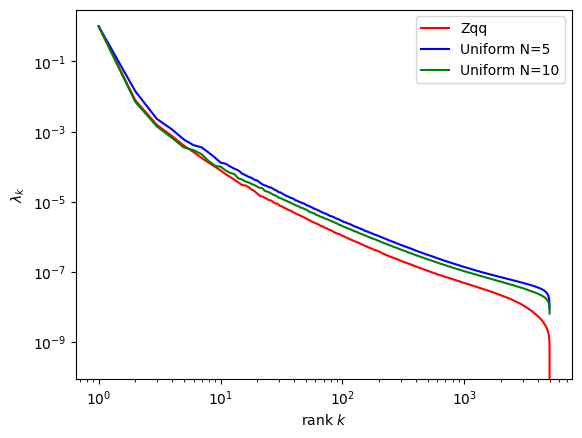

In [23]:
## Plot NTK Spectrum
i = np.arange(1, len(NTK_spec_Zqq)+1)
plt.loglog(i, NTK_spec_Zqq/NTK_spec_Zqq[0], ms=2, color='r', linestyle='-'); 
plt.loglog(i, NTK_spec_uN5/NTK_spec_uN5[0], ms=2, color='b', linestyle='-'); 
plt.loglog(i, NTK_spec_uN10/NTK_spec_uN10[0], ms=2, color='g', linestyle='-'); 
plt.legend(['Zqq', 'Uniform N=5', 'Uniform N=10'])
plt.xlabel(r'rank $k$'); plt.ylabel(r'$\lambda_k$')

In [24]:
Ps = np.unique(np.round(np.logspace(0, 4.5, 50)).astype(int))   


EFPs -> Thrust Regression

In [25]:
λs = [1e-10]
n_reps = lambda P: max(int(5_000 / P), 50)
NTK_losses_Z, NTK_losses_N3, NTK_losses_N5, NTK_losses_N10 = {}, {}, {}, {}
for λ in λs: 
    NTK_losses_Z[λ]  = run_regression_sweep(EFPs_Zqq, thrusts['Z->qqbar'],  Ps, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                        w_true=None, filter_zero_var=True, center=True, scale=True, kern="NTK")
    # losses_N3[r] = run_torch_regression(EFPs_N3_composite,  thrusts['uniform N=3'], train_sizes_t, r=r)
    NTK_losses_N5[λ] = run_regression_sweep(EFPs_N5,  thrusts['uniform N=5'], Ps, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                        w_true=None, filter_zero_var=True, center=True, scale=True, kern="NTK")
    NTK_losses_N10[λ] = run_regression_sweep(EFPs_N10,  thrusts['uniform N=10'], Ps, λ=λ, n_repeats=n_reps, test_size=0.2, 
                                         w_true=None, filter_zero_var=True, center=True, scale=True, kern="NTK")

(80000, 20) (20000, 20) 51.2 GB per train Gram


: 

3.9102927210705316e-05
0.0003504662808988749
0.0003394472990152592


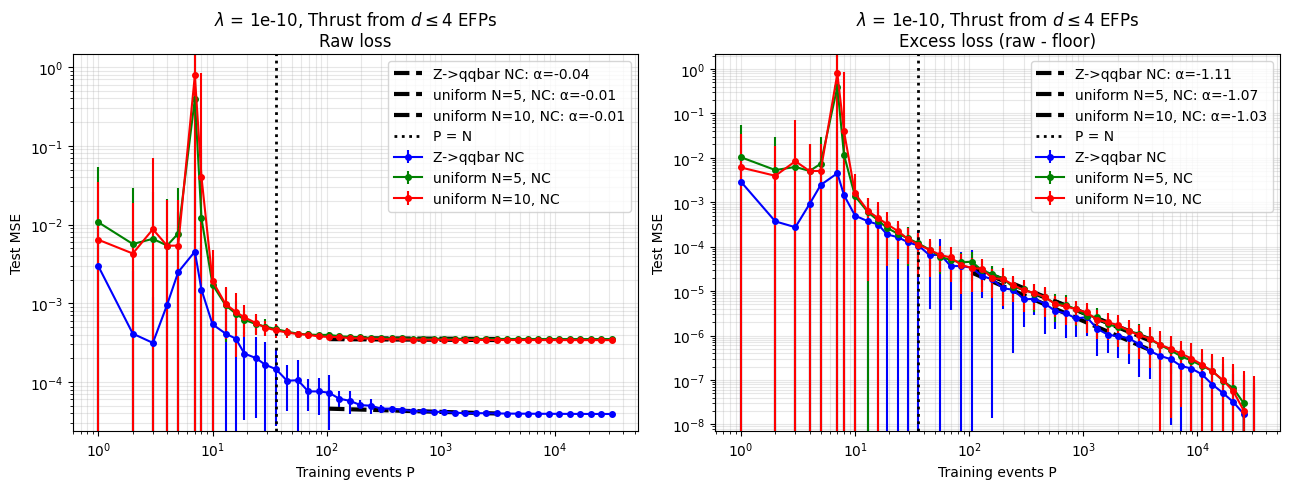

In [36]:
fit_min, fit_max = 100, 4000
ridgeparam=1e-10
all_results = {
    'Z->qqbar NC':    NTK_losses_Z[ridgeparam],
    # 'uniform N=3': losses_N3[ridgeparam],
    'uniform N=5, NC': NTK_losses_N5[ridgeparam],
    'uniform N=10, NC': NTK_losses_N10[ridgeparam],
    # 'uniform N=5, C': losses_N5_comp[ridgeparam],
    # 'uniform N=10, C': losses_N10_comp[ridgeparam],
}
colors = {
    'Z->qqbar NC': 'b', 
        #   'uniform N=3': 'b',
            'uniform N=5, NC': 'g',
            'uniform N=10, NC': 'r',
    # 'uniform N=5, C': 'b',
    # 'uniform N=10, C': 'orange'
            }

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, (losses, stds) in all_results.items():
    color = colors[name]
    floor = losses[-1]
    # print(floor)
    # floor = fit_floor(Ps_NC, losses, fit_min, fit_max, p0=None)[2]
    print(floor)
    excess = np.array(losses) - floor
    ps = np.array(Ps) if name[-2]=='N' else np.array(Ps_C)
    err1 = stds/np.sqrt(np.array([n_reps(p) for p in ps]))
    err2 = stds

    # axes[0].loglog(ps, losses, 'o-', color=color, markersize=4, label=name)
    # axes[1].loglog(ps, excess, 'o-', color=color, markersize=4, label=name)
    axes[0].errorbar(ps, losses, yerr=err2, fmt='o-', color=color, markersize=4, label=name)
    axes[1].errorbar(ps, excess, yerr=err2, fmt='o-', color=color, markersize=4, label=name)
    axes[0].set_xscale('log'); axes[0].set_yscale('log')
    axes[1].set_xscale('log'); axes[1].set_yscale('log')

    for ax, ls in zip(axes, [np.array(losses), excess]):
        mask = (ps >= fit_min) & (ps <= fit_max) & (ls > 0)
        if mask.sum() >= 2:
            slope, log_c = np.polyfit(np.log(ps[mask]), np.log(ls[mask]), 1, w=ls[mask]/err1[mask])

            ax.loglog(ps[mask], np.exp(log_c)*ps[mask]**slope, '--', color='k', linewidth=3,
                      label=f'{name}: α={slope:.2f}')
            # ax.axvspan(fit_min, fit_max, alpha=0.05, color=color)

for ax, title in zip(axes, ['Raw loss', 'Excess loss (raw - floor)']):
    # ax.set_ylim(1e-15, 1e1)
    ax.axvline(np.shape(EFPs_N5)[1], color='k', linestyle=':', linewidth=2, label='P = N')
    ax.set_xlabel('Training events P'); ax.set_ylabel('Test MSE')
    ax.set_title(f'$\lambda$ = 1e-10, Thrust from $d\leq 4$ EFPs\n{title}'); ax.legend(); ax.grid(True, which='both', alpha=0.3)

plt.tight_layout(); plt.show()

## DNN: EFPs → Thrust